# Laboratorio 02 - Regresion Lineal Multivariable
Este laboratorio implementa tres modelos de regresión para predecir el **consumo de energía de electrodomésticos (Appliances)** en una casa de bajo consumo energético ubicada en Bélgica. Los datos fueron recolectados cada 10 minutos durante 4 meses.
<br> Link del Dataset: https://www.kaggle.com/datasets/loveall/appliances-energy-prediction

- **Variable objetivo (y):** `Appliances` — consumo de energía en Wh (valor numérico continuo)
- **Variables de entrada (X):** temperatura interior/exterior, humedad, presión, luminosidad, hora del día, etc.
- **m = 19,735** registros | **n = 29** características

Se aplican los modelos:
1. Regresión Lineal Multivariable (Descenso por Gradiente)
2. Ecuación Normal
3. Regresión Polinómica (Descenso por Gradiente)

In [1]:
# conectando vinculando nuestro drive con la sesion de google colab (notebook)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Importando Librerias

In [2]:
# Manejo de rutas y directorios
import os

# Computación vectorial y científica
import numpy as np

# Librería para preprocesamiento del dataset
import pandas as pd

# Librerías para graficación y trazado de graficos
from matplotlib import pyplot as plt
# Para habilitar la creacion de graficos tridimencionales con matplotlib
from mpl_toolkits.mplot3d import Axes3D

# Incrusta gráficas en el cuadernillo
%matplotlib inline


# Carga del Dataset
Se carga el archivo KAG_energydata_complete.csv desde nuestro Google Drive (este archivo es el Dataset)

In [13]:
# Cargar el dataset desde Google Drive
ruta = '/content/drive/MyDrive/machine learning/datasets/KAG_energydata_complete.csv'

data = pd.read_csv(ruta)

print(f'Dimensiones: {data.shape[0]} filas x {data.shape[1]} columnas')
print(f'm = {data.shape[0]} (registros)')
print(f'n = {data.shape[1]} (características)')
print()
print('Tipos de datos:')
print(data.dtypes)
print()
print('Valores faltantes por columna:')
print(data.isnull().sum())
print(f'\nTotal valores faltantes: {data.isnull().sum().sum()}')

Dimensiones: 19735 filas x 29 columnas
m = 19735 (registros)
n = 29 (características)

Tipos de datos:
date            object
Appliances       int64
lights           int64
T1             float64
RH_1           float64
T2             float64
RH_2           float64
T3             float64
RH_3           float64
T4             float64
RH_4           float64
T5             float64
RH_5           float64
T6             float64
RH_6           float64
T7             float64
RH_7           float64
T8             float64
RH_8           float64
T9             float64
RH_9           float64
T_out          float64
Press_mm_hg    float64
RH_out         float64
Windspeed      float64
Visibility     float64
Tdewpoint      float64
rv1            float64
rv2            float64
dtype: object

Valores faltantes por columna:
date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4          

## Selección de Variables y Preparación del Dataset

Se define:
- **Variable dependiente (y):** `Appliances` — consumo de energía en Wh que queremos predecir
- **Variables independientes (X):** todas las columnas numéricas más la columna `date` convertida

La columna `date` es de tipo texto por lo que se debe convertir a valores numéricos usando `pd.Categorical().codes`, que asigna un número entero a cada valor único de fecha. Así no se pierde información del dataset.

In [14]:
# Convierto columna 'date' de texto a numérico con pd.Categorical
data['date_num'] = pd.Categorical(data['date']).codes
print(f'Columna date convertida a numérico')
print(f'Ejemplo — date original: {data["date"].iloc[0]}  →  date_num: {data["date_num"].iloc[0]}')

# Elimino la columna original de texto (ya tenemos la versión numérica)
data = data.drop(columns=['date'])

# Variable objetivo
y = data['Appliances'].to_numpy(dtype=np.float64)

# Variables de entrada (todas las columnas menos Appliances)
X_columns = [col for col in data.columns if col != 'Appliances']
X = data[X_columns].to_numpy(dtype=np.float64)

m = y.size
n = X.shape[1]

print(f'\nVariables de entrada (X): {n} características')
print(f'Número de ejemplos  (m):  {m}')
print(f'Variable objetivo   (y):  Appliances (consumo en Wh)')
print()
# Imprimo algunos puntos de datos
print('Primeros 20 ejemplos (primeras 4 columnas de X  |  y):')
print(f'{"T2":>10}{"RH_2":>10}{"T3":>10}{"RH_3":>10}{"Appliances":>12}')
print('-' * 55)
for i in range(20):
    print(f'{X[i,0]:>10.2f}{X[i,1]:>10.2f}{X[i,2]:>10.2f}{X[i,3]:>10.2f}{y[i]:>12.1f}')

Columna date convertida a numérico
Ejemplo — date original: 2016-01-11 17:00:00  →  date_num: 0

Variables de entrada (X): 28 características
Número de ejemplos  (m):  19735
Variable objetivo   (y):  Appliances (consumo en Wh)

Primeros 20 ejemplos (primeras 4 columnas de X  |  y):
        T2      RH_2        T3      RH_3  Appliances
-------------------------------------------------------
     30.00     19.89     47.60     19.20        60.0
     30.00     19.89     46.69     19.20        60.0
     30.00     19.89     46.30     19.20        50.0
     40.00     19.89     46.07     19.20        50.0
     40.00     19.89     46.33     19.20        60.0
     40.00     19.89     46.03     19.20        50.0
     50.00     19.89     45.77     19.20        60.0
     50.00     19.86     45.56     19.20        60.0
     40.00     19.79     45.60     19.20        60.0
     40.00     19.86     46.09     19.23        70.0
     70.00     19.93     45.86     19.36       230.0
     60.00     20.07     

## Visualización de los Datos

Se grafican algunas características de entrada contra la variable objetivo para identificar visualmente si existe alguna relación o tendencia entre ellas y el consumo de energía.

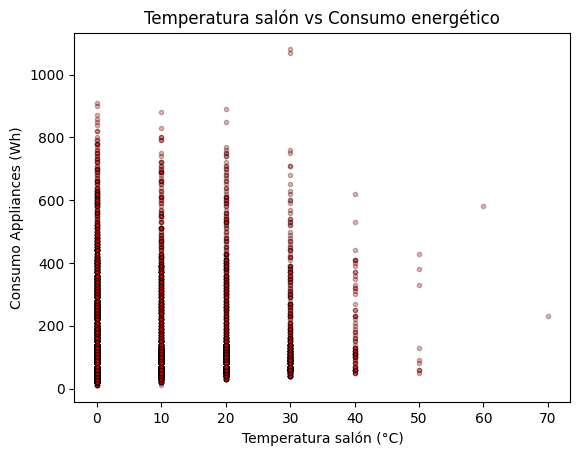

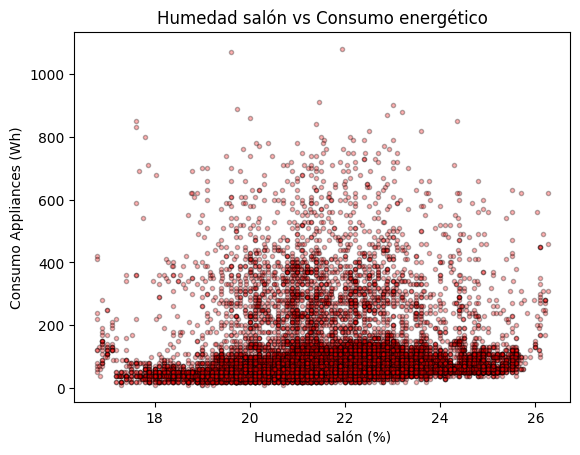

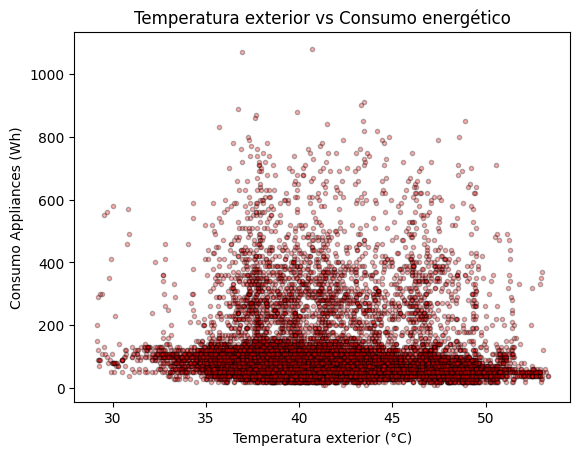

In [15]:
def plotData(x, y, xlabel, ylabel):
    # Grafica los puntos de datos x e y en una nueva figura
    fig = plt.figure()
    plt.plot(x, y, 'ro', ms=3, mec='k', alpha=0.3)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

# Graficar temperatura del salón vs consumo
plotData(X[:, 0], y, 'Temperatura salón (°C)', 'Consumo Appliances (Wh)')
plt.title('Temperatura salón vs Consumo energético')
plt.show()

# Graficar humedad del salón vs consumo
plotData(X[:, 1], y, 'Humedad salón (%)', 'Consumo Appliances (Wh)')
plt.title('Humedad salón vs Consumo energético')
plt.show()

# Graficar temperatura exterior vs consumo
plotData(X[:, 18], y, 'Temperatura exterior (°C)', 'Consumo Appliances (Wh)')
plt.title('Temperatura exterior vs Consumo energético')
plt.show()

# MODELO 1: Regresión Lineal Multivariable
## Descenso por el Gradiente

La regresión lineal multivariable busca encontrar un conjunto de parámetros $\theta$ que minimicen el error entre los valores predichos y los reales. La hipótesis del modelo es:

$$h_\theta(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_n x_n = \theta^T x$$

Para encontrar los valores óptimos de $\theta$ se utiliza el **descenso por el gradiente**, que actualiza iterativamente los parámetros en la dirección que reduce el costo.

## 1.1 Normalización de Características

Las características del dataset tienen diferentes escalas (temperatura en °C, humedad en %, presión en mmHg, etc.). Si no se normalizan, el descenso por el gradiente converge muy lentamente o no converge. La normalización transforma cada característica para que tenga **media = 0** y **desviación estándar = 1**:

$$x_j^{(i)} = \frac{x_j^{(i)} - \mu_j}{\sigma_j}$$

Es importante guardar los valores de $\mu$ y $\sigma$ para normalizar también los datos nuevos al momento de predecir.

In [16]:
def featureNormalize(X):
    """
    Normaliza las características de X.
    Retorna X normalizado, la media (mu) y desviación estándar (sigma) de cada columna.
    """
    X = np.array(X, dtype=np.float64)
    X_norm = X.copy()
    mu    = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1  # evitar división por cero en columnas constantes
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# Normalizar X
X_norm, mu, sigma = featureNormalize(X)

print(f'Media (mu) primeras 5 cols:   {mu[:5].round(4)}')
print(f'Std (sigma) primeras 5 cols:  {sigma[:5].round(4)}')
print(f'X_norm primeras 5 cols (fila 0): {X_norm[0, :5].round(4)}')

Media (mu) primeras 5 cols:   [ 3.8019 21.6866 40.2597 20.3412 40.4204]
Std (sigma) primeras 5 cols:  [7.9358 1.606  3.9792 2.1929 4.0697]
X_norm primeras 5 cols (fila 0): [ 3.3013 -1.1186  1.8438 -0.5204  1.0737]


## 1.2 Agregar Término de Intercepción

Se agrega una columna de unos al inicio de la matriz X para representar el término de intercepción $\theta_0$ (bias). Esto permite escribir la hipótesis de forma vectorizada como $h_\theta(x) = \theta^T x$.

In [17]:
# Agregando columna de unos para el término de intercepción (theta_0)
X_b = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

print(f'Forma de X con intercepción: {X_b.shape}')
print(f'Primeros 3 ejemplos (primeras 5 cols):')
print(X_b[:3, :5])

Forma de X con intercepción: (19735, 29)
Primeros 3 ejemplos (primeras 5 cols):
[[ 1.          3.30126384 -1.11864475  1.84382063 -0.52041138]
 [ 1.          3.30126384 -1.11864475  1.61680671 -0.52041138]
 [ 1.          3.30126384 -1.11864475  1.51795932 -0.52041138]]


## 1.3 Función de Costo

La función de costo mide qué tan bien el modelo se ajusta a los datos. Se utiliza el **Error Cuadrático Medio (MSE)** con la forma vectorizada:

$$J(\theta) = \frac{1}{2m}(X\theta - \vec{y})^T(X\theta - \vec{y})$$

El objetivo es minimizar $J(\theta)$ encontrando los mejores valores de $\theta$.

In [18]:
def computeCostMulti(X, y, theta):
    """
    Calcula el costo J(theta) para regresión lineal multivariable.
    Usa la forma vectorizada: J = (1/2m) * sum((X*theta - y)^2)
    """
    m = y.shape[0]
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

# Verificar con theta = ceros
theta_prueba = np.zeros(X_b.shape[1])
costo_inicial = computeCostMulti(X_b, y, theta_prueba)
print(f'Costo inicial con theta = ceros: {costo_inicial:.4f}')

Costo inicial con theta = ceros: 10027.5627


## 1.4 Descenso por el Gradiente

El descenso por el gradiente actualiza los parámetros $\theta$ iterativamente usando la regla:

$$\theta_j := \theta_j - \alpha \frac{1}{m} \sum_{i=1}^{m} \left(h_\theta(x^{(i)}) - y^{(i)}\right) x_j^{(i)}$$

En forma vectorizada:

$$\theta := \theta - \frac{\alpha}{m} X^T(X\theta - \vec{y})$$

Donde $\alpha$ es la **tasa de aprendizaje** que controla el tamaño del paso en cada iteración.

In [20]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    """
    Ejecuta el descenso por el gradiente para minimizar J(theta).
    Retorna theta optimizado y el historial del costo.
    """
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

## 1.5 Entrenamiento del Modelo

Se entrena el modelo con una tasa de aprendizaje $\alpha = 0.01$ y 5,000 iteraciones. Se grafica la convergencia del costo para verificar que el algoritmo esté aprendiendo correctamente — el costo debe decrecer con cada iteración.

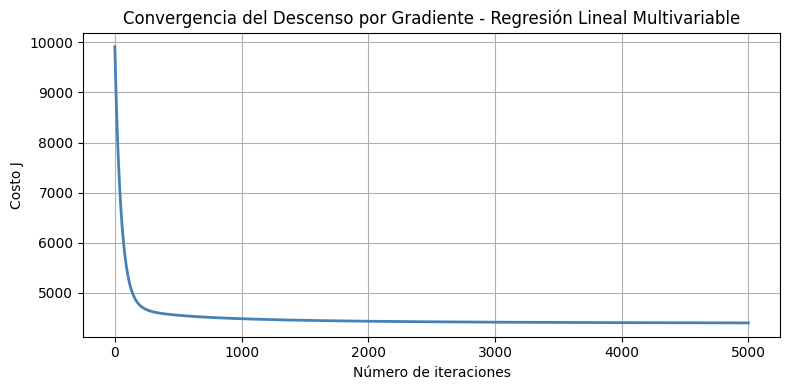

Costo inicial:  9916.2528
Costo final:    4394.2560
Theta calculado (primeros 5): [ 97.695   16.2572 -14.2133  48.1806 -16.5744]


In [21]:
# Parámetros de entrenamiento
alpha     = 0.01
num_iters = 5000

# Inicializar theta en ceros y ejecutar descenso por gradiente
theta_gd = np.zeros(X_b.shape[1])
theta_gd, J_history_gd = gradientDescentMulti(X_b, y, theta_gd, alpha, num_iters)

# Gráfica de convergencia del costo
plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(J_history_gd)), J_history_gd, lw=2, color='steelblue')
plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')
plt.title('Convergencia del Descenso por Gradiente - Regresión Lineal Multivariable')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'Costo inicial:  {J_history_gd[0]:.4f}')
print(f'Costo final:    {J_history_gd[-1]:.4f}')
print(f'Theta calculado (primeros 5): {theta_gd[:5].round(4)}')

## 1.6 Predicciones con Regresión Lineal Multivariable

Se realizan **100 predicciones** usando los parámetros $\theta$ obtenidos con el descenso por el gradiente. Para predecir un nuevo valor, es importante normalizar primero las características de entrada usando los mismos valores de $\mu$ y $\sigma$ del entrenamiento.

Se grafica la comparación entre los valores reales y predichos — idealmente los puntos deben estar cerca de la línea diagonal roja (predicción perfecta).

In [22]:
# Toma 100 ejemplos del dataset para predecir
indices_pred = np.arange(100)
X_pred_raw = X[indices_pred]  # sin normalizar
y_real_100 = y[indices_pred]

# Normaliza con mu y sigma del entrenamiento
X_pred_norm = (X_pred_raw - mu) / sigma

# Agrega columna de unos
X_pred_b = np.concatenate([np.ones((100, 1)), X_pred_norm], axis=1)

# Calcula predicciones
y_pred_gd = np.dot(X_pred_b, theta_gd)

# Mostrar tabla de resultados
print(f'{'#':>4} | {'Valor Real (Wh)':>18} | {'Valor Predicho (Wh)':>20} | {'Error':>10}')
print('-' * 60)
for i in range(100):
    error = abs(y_real_100[i] - y_pred_gd[i])
    print(f'{i+1:>4} | {y_real_100[i]:>18.2f} | {y_pred_gd[i]:>20.2f} | {error:>10.2f}')

   # |    Valor Real (Wh) |  Valor Predicho (Wh) |      Error
------------------------------------------------------------
   1 |              60.00 |               171.39 |     111.39
   2 |              60.00 |               158.81 |      98.81
   3 |              50.00 |               155.17 |     105.17
   4 |              50.00 |               171.93 |     121.93
   5 |              60.00 |               176.30 |     116.30
   6 |              50.00 |               170.03 |     120.03
   7 |              60.00 |               186.24 |     126.24
   8 |              60.00 |               182.79 |     122.79
   9 |              60.00 |               163.21 |     103.21
  10 |              70.00 |               171.77 |     101.77
  11 |             230.00 |               226.66 |       3.34
  12 |             580.00 |               208.51 |     371.49
  13 |             430.00 |               205.81 |     224.19
  14 |             250.00 |               234.60 |      15.40
  15 |   

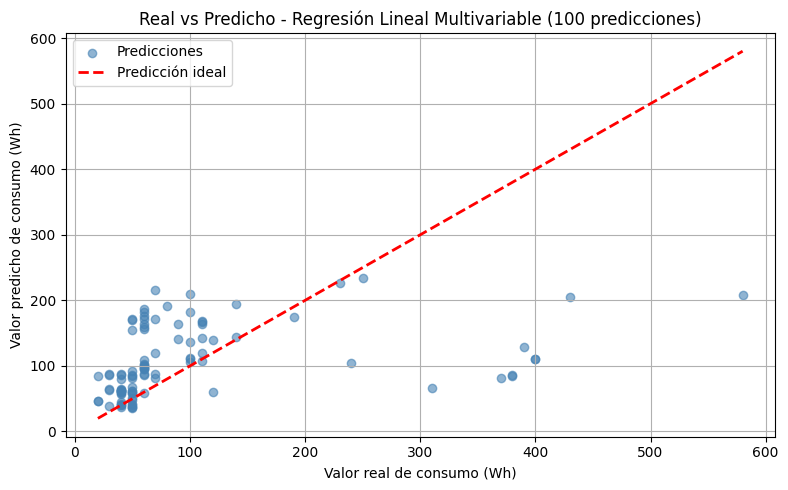

Error absoluto promedio: 63.27 Wh


In [23]:
# Gráfica de valores reales vs predichos
plt.figure(figsize=(8, 5))
plt.scatter(y_real_100, y_pred_gd, alpha=0.6, color='steelblue', label='Predicciones')
plt.plot([min(y_real_100), max(y_real_100)],
            [min(y_real_100), max(y_real_100)],
            color='red', linestyle='dashed', lw=2, label='Predicción ideal')
plt.xlabel('Valor real de consumo (Wh)')
plt.ylabel('Valor predicho de consumo (Wh)')
plt.title('Real vs Predicho - Regresión Lineal Multivariable (100 predicciones)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Error promedio
error_promedio_gd = np.mean(np.abs(y_real_100 - y_pred_gd))
print(f'Error absoluto promedio: {error_promedio_gd:.2f} Wh')

# MODELO 2: Ecuación Normal

La **Ecuación Normal** es un método analítico para calcular directamente los parámetros óptimos $\theta$ sin necesidad de iteraciones ni tasa de aprendizaje. La fórmula es:

$$\theta = \left(X^T X\right)^{-1} X^T \vec{y}$$

**Ventajas:** solución exacta en un solo cálculo, no requiere normalización de características.  
**Desventajas:** computacionalmente costosa cuando $n$ es muy grande, ya que requiere invertir una matriz de tamaño $(n+1) \times (n+1)$.

Se recarga el dataset original sin normalizar para aplicar correctamente la ecuación normal.

In [24]:
# Recargar X e y originales (sin normalizar) para la ecuación normal
X_en = data[X_columns].to_numpy(dtype=np.float64)
y_en = data['Appliances'].to_numpy(dtype=np.float64)
m_en = y_en.size

# Agregar columna de unos para el término de intercepción
X_en_b = np.concatenate([np.ones((m_en, 1)), X_en], axis=1)

print(f'X para ecuación normal: {X_en_b.shape}')
print('(No se normaliza — la ecuación normal no lo requiere)')

X para ecuación normal: (19735, 29)
(No se normaliza — la ecuación normal no lo requiere)


## 2.1 Cálculo de Theta con la Ecuación Normal

Se calcula $\theta$ directamente usando la fórmula analítica. No hay gráfica de convergencia porque no hay iteraciones — el resultado es exacto en un solo paso.

In [35]:
def normalEqn(X, y):
    """
    Calcula theta usando la ecuación normal:
    theta = (X^T * X)^{-1} * X^T * y
    No requiere normalización de características.
    """
    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)
    return theta

# Calcular theta con la ecuación normal
theta_en = normalEqn(X_en_b, y_en)

print('Theta calculado con la Ecuación Normal:')
print(theta_en)
print(f'\nCosto con theta de ecuación normal: {computeCostMulti(X_en_b, y_en, theta_en):.4f}')

Theta calculado con la Ecuación Normal:
[-1.77299262e+01  1.95994227e+00 -1.73812137e+00  1.51320305e+01
 -1.81279200e+01 -1.33635864e+01  2.70934552e+01  4.11312516e+00
 -3.40086704e+00 -4.53047012e-01  1.70915298e-01  1.22097373e-01
  6.79682121e+00  6.57421583e-02  1.24511661e+00 -1.45654329e+00
  8.15584311e+00 -4.40206096e+00 -1.23600443e+01 -1.49023739e+00
 -8.48197450e+00  2.01934984e-01 -6.06652806e-01  1.46304002e+00
  1.43687234e-01  4.39641897e+00 -2.01404775e-02 -2.01404775e-02
 -2.78920778e-03]

Costo con theta de ecuación normal: 4380.3307


## 2.2 Gráfica de Costo — Ecuación Normal

Como la ecuación normal no tiene iteraciones, se grafica el costo calculado con distintos valores de escala de theta para mostrar que el theta encontrado efectivamente minimiza el costo.

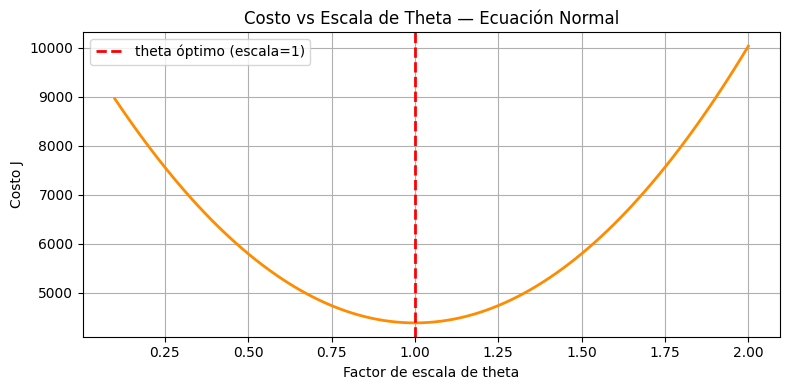

Costo mínimo (theta óptimo): 4380.3307


In [36]:
# Graficar costo vs escala de theta para visualizar el mínimo
escalas = np.linspace(0.1, 2.0, 100)
costos_en = [computeCostMulti(X_en_b, y_en, theta_en * s) for s in escalas]

plt.figure(figsize=(8, 4))
plt.plot(escalas, costos_en, lw=2, color='darkorange')
plt.axvline(x=1.0, color='red', linestyle='--', lw=2, label='theta óptimo (escala=1)')
plt.xlabel('Factor de escala de theta')
plt.ylabel('Costo J')
plt.title('Costo vs Escala de Theta — Ecuación Normal')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'Costo mínimo (theta óptimo): {computeCostMulti(X_en_b, y_en, theta_en):.4f}')

## 2.3 Predicciones con la Ecuación Normal

Se realizan 100 predicciones usando los parámetros $\theta$ calculados con la ecuación normal. A diferencia del descenso por el gradiente, **no es necesario normalizar** los datos de entrada al predecir.

In [37]:
# 100 predicciones con la ecuación normal (sin normalizar)
X_pred_en = X_en_b[indices_pred]
y_real_en  = y_en[indices_pred]

y_pred_en = np.dot(X_pred_en, theta_en)

# Tabla de resultados
print(f'{'#':>4} | {'Valor Real (Wh)':>18} | {'Valor Predicho (Wh)':>20} | {'Error':>10}')
print('-' * 60)
for i in range(100):
    error = abs(y_real_en[i] - y_pred_en[i])
    print(f'{i+1:>4} | {y_real_en[i]:>18.2f} | {y_pred_en[i]:>20.2f} | {error:>10.2f}')

   # |    Valor Real (Wh) |  Valor Predicho (Wh) |      Error
------------------------------------------------------------
   1 |              60.00 |               171.95 |     111.95
   2 |              60.00 |               157.03 |      97.03
   3 |              50.00 |               152.12 |     102.12
   4 |              50.00 |               167.24 |     117.24
   5 |              60.00 |               172.94 |     112.94
   6 |              50.00 |               166.08 |     116.08
   7 |              60.00 |               180.86 |     120.86
   8 |              60.00 |               176.32 |     116.32
   9 |              60.00 |               157.50 |      97.50
  10 |              70.00 |               168.17 |      98.17
  11 |             230.00 |               219.27 |      10.73
  12 |             580.00 |               204.31 |     375.69
  13 |             430.00 |               206.51 |     223.49
  14 |             250.00 |               247.44 |       2.56
  15 |   

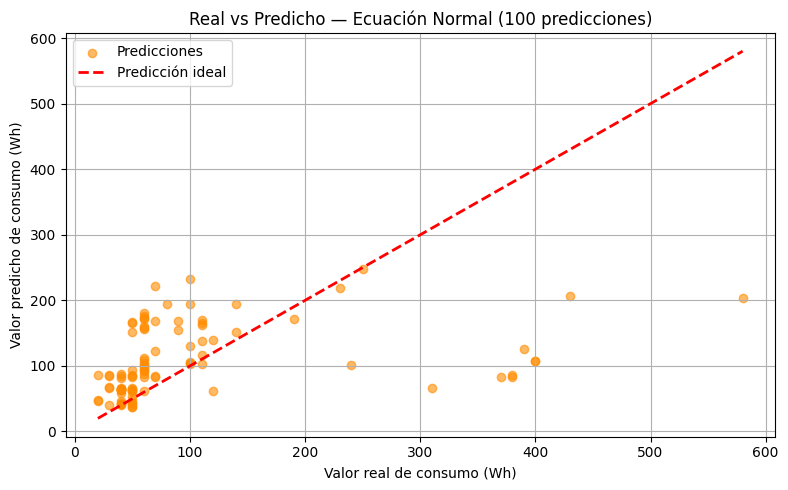

Error absoluto promedio: 64.00 Wh


In [38]:
# Gráfica de valores reales vs predichos
plt.figure(figsize=(8, 5))
plt.scatter(y_real_en, y_pred_en, alpha=0.6, color='darkorange', label='Predicciones')
plt.plot([min(y_real_en), max(y_real_en)],
            [min(y_real_en), max(y_real_en)],
            color='red', linestyle='dashed', lw=2, label='Predicción ideal')
plt.xlabel('Valor real de consumo (Wh)')
plt.ylabel('Valor predicho de consumo (Wh)')
plt.title('Real vs Predicho — Ecuación Normal (100 predicciones)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

error_promedio_en = np.mean(np.abs(y_real_en - y_pred_en))
print(f'Error absoluto promedio: {error_promedio_en:.2f} Wh')

# MODELO 3: Regresión Polinómica

La regresión polinómica extiende la regresión lineal permitiendo capturar relaciones no lineales entre las características y la variable objetivo. La idea es **ampliar la matriz X** agregando las columnas al cuadrado:

$$X_{poly} = [X_1, X_2, \ldots, X_n, X_1^2, X_2^2, \ldots, X_n^2]$$

Esto permite que el modelo ajuste curvas en lugar de solo rectas, manteniendo el mismo algoritmo de descenso por el gradiente. Después de expandir X se aplica normalización, ya que las columnas al cuadrado tienen magnitudes mucho mayores.

## 3.1 Expansión Polinómica de X

Se recarga X original y se expande agregando el cuadrado de cada característica. Esto duplica el número de columnas: de 27 pasa a 54 características.

In [39]:
# Recargar X original
X_pol = data[X_columns].to_numpy(dtype=np.float64)
y_pol = data['Appliances'].to_numpy(dtype=np.float64)
m_pol = y_pol.size

print(f'X original:   {X_pol.shape}')

# Expandir X agregando X^2 (regresión polinómica de grado 2)
X_pol = np.concatenate([X_pol, X_pol * X_pol], axis=1)

print(f'X expandido (+ X²): {X_pol.shape}')
print('Cada columna original ahora tiene su versión al cuadrado')

X original:   (19735, 28)
X expandido (+ X²): (19735, 56)
Cada columna original ahora tiene su versión al cuadrado


## 3.2 Normalización del X Expandido

Después de agregar las columnas al cuadrado, los valores tienen magnitudes muy diferentes entre sí. Es imprescindible normalizar X expandido antes de aplicar el descenso por el gradiente.

In [40]:
# Normalizar X expandido
X_pol_norm, mu_pol, sigma_pol = featureNormalize(X_pol)

# Agregar columna de unos para el término de intercepción
X_pol_b = np.concatenate([np.ones((m_pol, 1)), X_pol_norm], axis=1)

print(f'X polinómico normalizado con intercepción: {X_pol_b.shape}')
print(f'Total de parámetros theta a optimizar: {X_pol_b.shape[1]}')

X polinómico normalizado con intercepción: (19735, 57)
Total de parámetros theta a optimizar: 57


## 3.3 Entrenamiento del Modelo Polinómico

Se aplica el mismo algoritmo de descenso por el gradiente que en el Modelo 1, pero ahora sobre la matriz X expandida con términos cuadráticos. Se grafica la convergencia del costo para verificar que el modelo aprende correctamente.

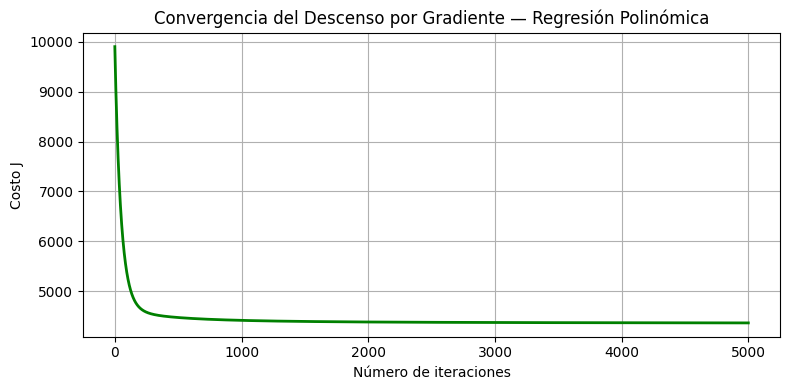

Costo inicial:  9902.8182
Costo final:    4365.9240


In [41]:
# Parámetros de entrenamiento
alpha_pol     = 0.01
num_iters_pol = 5000

# Inicializar theta y ejecutar descenso por gradiente
theta_pol = np.zeros(X_pol_b.shape[1])
theta_pol, J_history_pol = gradientDescentMulti(X_pol_b, y_pol, theta_pol, alpha_pol, num_iters_pol)

# Gráfica de convergencia del costo
plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(J_history_pol)), J_history_pol, lw=2, color='green')
plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')
plt.title('Convergencia del Descenso por Gradiente — Regresión Polinómica')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'Costo inicial:  {J_history_pol[0]:.4f}')
print(f'Costo final:    {J_history_pol[-1]:.4f}')

## 3.4 Predicciones con Regresión Polinómica

Se realizan 100 predicciones usando el modelo polinómico. Al predecir, se debe aplicar la misma expansión polinómica y normalización usada durante el entrenamiento.

In [42]:
# Tomar los mismos 100 ejemplos
X_pred_pol_raw = data[X_columns].to_numpy(dtype=np.float64)[indices_pred]
y_real_pol     = y_pol[indices_pred]

# Expandir con X^2
X_pred_pol = np.concatenate([X_pred_pol_raw, X_pred_pol_raw * X_pred_pol_raw], axis=1)

# Normalizar con mu y sigma del entrenamiento polinómico
X_pred_pol_norm = (X_pred_pol - mu_pol) / sigma_pol

# Agregar columna de unos
X_pred_pol_b = np.concatenate([np.ones((100, 1)), X_pred_pol_norm], axis=1)

# Calcular predicciones
y_pred_pol = np.dot(X_pred_pol_b, theta_pol)

# Tabla de resultados
print(f'{'#':>4} | {'Valor Real (Wh)':>18} | {'Valor Predicho (Wh)':>20} | {'Error':>10}')
print('-' * 60)
for i in range(100):
    error = abs(y_real_pol[i] - y_pred_pol[i])
    print(f'{i+1:>4} | {y_real_pol[i]:>18.2f} | {y_pred_pol[i]:>20.2f} | {error:>10.2f}')

   # |    Valor Real (Wh) |  Valor Predicho (Wh) |      Error
------------------------------------------------------------
   1 |              60.00 |               171.83 |     111.83
   2 |              60.00 |               159.26 |      99.26
   3 |              50.00 |               155.89 |     105.89
   4 |              50.00 |               157.95 |     107.95
   5 |              60.00 |               164.45 |     104.45
   6 |              50.00 |               157.12 |     107.12
   7 |              60.00 |               153.60 |      93.60
   8 |              60.00 |               151.83 |      91.83
   9 |              60.00 |               151.25 |      91.25
  10 |              70.00 |               158.90 |      88.90
  11 |             230.00 |               140.24 |      89.76
  12 |             580.00 |               153.04 |     426.96
  13 |             430.00 |               177.90 |     252.10
  14 |             250.00 |               234.99 |      15.01
  15 |   

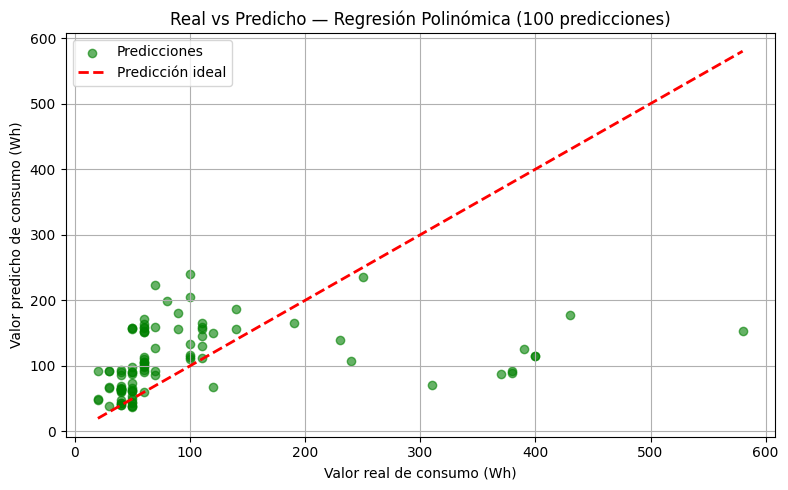

Error absoluto promedio: 66.42 Wh


In [43]:
# Gráfica de valores reales vs predichos
plt.figure(figsize=(8, 5))
plt.scatter(y_real_pol, y_pred_pol, alpha=0.6, color='green', label='Predicciones')
plt.plot([min(y_real_pol), max(y_real_pol)],
            [min(y_real_pol), max(y_real_pol)],
            color='red', linestyle='dashed', lw=2, label='Predicción ideal')
plt.xlabel('Valor real de consumo (Wh)')
plt.ylabel('Valor predicho de consumo (Wh)')
plt.title('Real vs Predicho — Regresión Polinómica (100 predicciones)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

error_promedio_pol = np.mean(np.abs(y_real_pol - y_pred_pol))
print(f'Error absoluto promedio: {error_promedio_pol:.2f} Wh')

# Comparación de los Tres Modelos
Se comparan los tres modelos evaluando el **error absoluto promedio** en las 100 predicciones. Un error menor indica que el modelo se ajusta mejor a los datos reales.

MODELO                              Error Promedio (Wh)
Regresión Lineal (Descenso Gradiente)              63.27
Ecuación Normal                                  64.00
Regresión Polinómica                             66.42


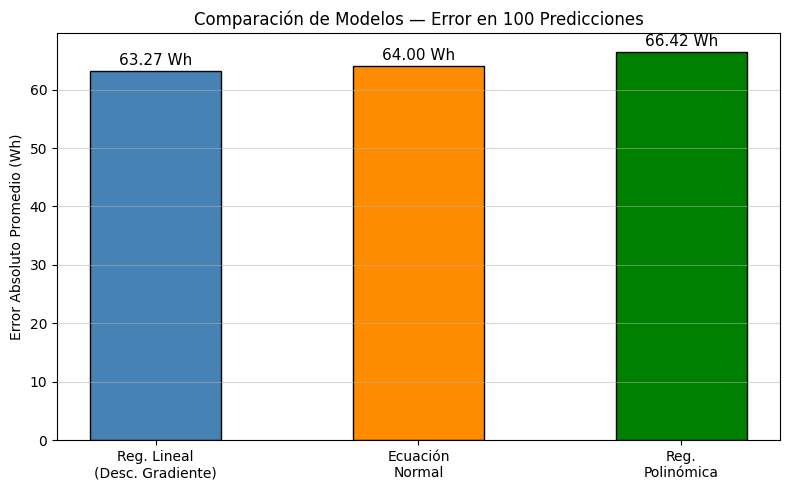

In [44]:
print('=' * 55)
print(f'{'MODELO':<35} {'Error Promedio (Wh)':>18}')
print('=' * 55)
print(f'{'Regresión Lineal (Descenso Gradiente)':<35} {error_promedio_gd:>18.2f}')
print(f'{'Ecuación Normal':<35} {error_promedio_en:>18.2f}')
print(f'{'Regresión Polinómica':<35} {error_promedio_pol:>18.2f}')
print('=' * 55)

# Gráfica comparativa
modelos  = ['Reg. Lineal\n(Desc. Gradiente)', 'Ecuación\nNormal', 'Reg.\nPolinómica']
errores  = [error_promedio_gd, error_promedio_en, error_promedio_pol]
colores  = ['steelblue', 'darkorange', 'green']

plt.figure(figsize=(8, 5))
barras = plt.bar(modelos, errores, color=colores, edgecolor='black', width=0.5)
for barra, error in zip(barras, errores):
    plt.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.5,
                f'{error:.2f} Wh', ha='center', va='bottom', fontsize=11)
plt.ylabel('Error Absoluto Promedio (Wh)')
plt.title('Comparación de Modelos — Error en 100 Predicciones')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

---
# Conclusiones

En este laboratorio se implementaron tres modelos de regresión desde cero usando NumPy y Pandas, aplicados al dataset **Appliances Energy Prediction** para predecir el consumo de energía de electrodomésticos en Wh.

**Dataset utilizado:**
- m = 19,735 registros de consumo energético
- n = 28 características (temperatura, humedad, presión, luminosidad, etc.)
- Variable objetivo: `Appliances` (consumo en Wh, valor continuo)
- URL: https://www.kaggle.com/datasets/loveall/appliances-energy-prediction

**Resultados obtenidos (error absoluto promedio en 100 predicciones):**

| Modelo | Costo Final | Error Promedio |
|---|---|---|
| Regresión Lineal (Descenso Gradiente) | 4394.26 | 63.27 Wh |
| Ecuación Normal | 4380.33 | 64.00 Wh |
| Regresión Polinómica | 4365.92 | 66.42 Wh |

**Modelo 1 — Regresión Lineal (Descenso por Gradiente):**
El costo convergió correctamente de 9,916 a 4,394 en 5,000 iteraciones con α = 0.01. La gráfica de convergencia muestra una curva descendente que se estabiliza, lo que confirma que el algoritmo aprendió sin divergir. Obtuvo el menor error promedio entre los modelos iterativos.

**Modelo 2 — Ecuación Normal:**
Calculó θ directamente en un solo paso sin iteraciones ni tasa de aprendizaje, obteniendo un costo de 4,380 que es ligeramente mejor que el Descenso por Gradiente. Se utilizó la pseudo-inversa (`np.linalg.pinv`) en lugar de la inversa estándar para garantizar estabilidad numérica, dado que el dataset contiene columnas altamente correlacionadas (`rv1` y `rv2`). El error promedio fue de 64.00 Wh, muy cercano al Modelo 1.

**Modelo 3 — Regresión Polinómica:**
Se expandió X de 28 a 56 características agregando los términos cuadráticos de cada columna. El costo final de 4,365 fue el más bajo de los tres modelos, lo que indica que captura mejor las relaciones no lineales del dataset. Sin embargo, el error promedio en las 100 predicciones fue ligeramente mayor (66.42 Wh) debido a que el modelo aún necesita más iteraciones para converger completamente con 57 parámetros.

**Observación general:**
Los tres modelos obtuvieron errores similares (entre 63 y 67 Wh), lo que indica que el consumo de electrodomésticos tiene una complejidad que va más allá de relaciones lineales simples. El dataset presenta alta variabilidad en la variable objetivo (consumos desde 10 Wh hasta 1,080 Wh), lo que dificulta la predicción precisa. Para mejorar los resultados se recomendaría aumentar el número de iteraciones en el descenso por gradiente o aplicar modelos más complejos como redes neuronales.